In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# 1. Load data

df = pd.read_csv("bank_transactions_data_2.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (2512, 16)

First 5 rows:
  TransactionID AccountID  TransactionAmount      TransactionDate  \
0      TX000001   AC00128              14.09  2023-04-11 16:29:14   
1      TX000002   AC00455             376.24  2023-06-27 16:44:19   
2      TX000003   AC00019             126.29  2023-07-10 18:16:08   
3      TX000004   AC00070             184.50  2023-05-05 16:32:11   
4      TX000005   AC00411              13.45  2023-10-16 17:51:24   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0           70        

In [3]:
# 2. Duplicate checks

print("\nFull duplicate rows:", df.duplicated().sum())
print("Duplicate TransactionID:", df["TransactionID"].duplicated().sum())


Full duplicate rows: 0
Duplicate TransactionID: 0


In [4]:
# 3. Datetime transformation

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"], errors="coerce")

In [5]:
# 4. Initial feature derivation

df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Month"] = df["TransactionDate"].dt.month
df["DayOfWeek"] = df["TransactionDate"].dt.day_name()
df["IsWeekend"] = df["TransactionDate"].dt.dayofweek.isin([5, 6]).astype(int)

df["TimeSincePrevTxnHours"] = (df["TransactionDate"] - df["PreviousTransactionDate"]).dt.total_seconds() / 3600

# absolute gap is more robust if dates are inconsistent

df["AbsTimeGapHours"] = df["TimeSincePrevTxnHours"].abs()

In [6]:
# 5. Data understanding

print("\nUnique Accounts:", df["AccountID"].nunique())
print("Unique Merchants:", df["MerchantID"].nunique())
print("Unique Locations:", df["Location"].nunique())

print("\nTransaction Type Distribution:")
print(df["TransactionType"].value_counts(normalize=True) * 100)

print("\nChannel Distribution:")
print(df["Channel"].value_counts(normalize=True) * 100)

print("\nNumeric Summary:")
print(df.describe().T)


Unique Accounts: 495
Unique Merchants: 100
Unique Locations: 43

Transaction Type Distribution:
TransactionType
Debit     77.388535
Credit    22.611465
Name: proportion, dtype: float64

Channel Distribution:
Channel
Branch    34.554140
ATM       33.160828
Online    32.285032
Name: proportion, dtype: float64

Numeric Summary:
                          count                           mean  \
TransactionAmount        2512.0                     297.593778   
TransactionDate            2512  2023-07-05 20:32:10.826433024   
CustomerAge              2512.0                      44.673965   
TransactionDuration      2512.0                     119.643312   
LoginAttempts            2512.0                       1.124602   
AccountBalance           2512.0                    5114.302966   
PreviousTransactionDate    2512  2024-11-04 08:09:22.219745024   
Hour                     2512.0                      16.626194   
Day                      2512.0                      15.827229   
Month       

In [7]:
# 6. Univariate Analysis

numeric_cols = ["TransactionAmount", "CustomerAge", "TransactionDuration","LoginAttempts", "AccountBalance", "Hour", "AbsTimeGapHours"]

categorical_cols = ["TransactionType", "Location", "Channel", "CustomerOccupation", "DayOfWeek"]

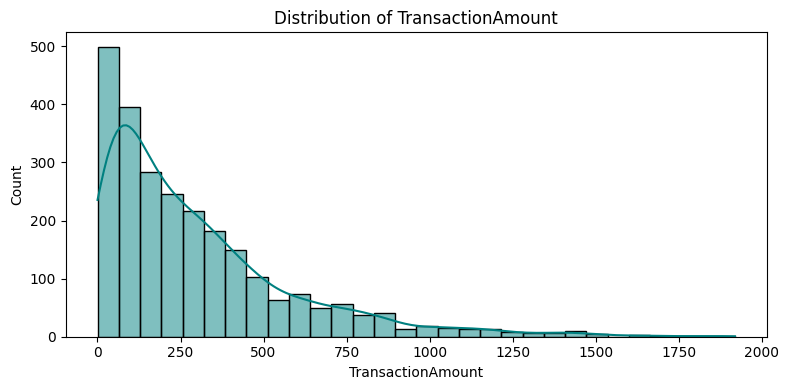

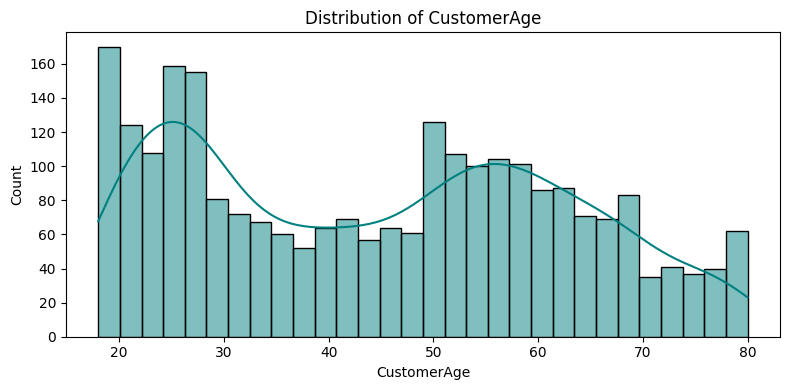

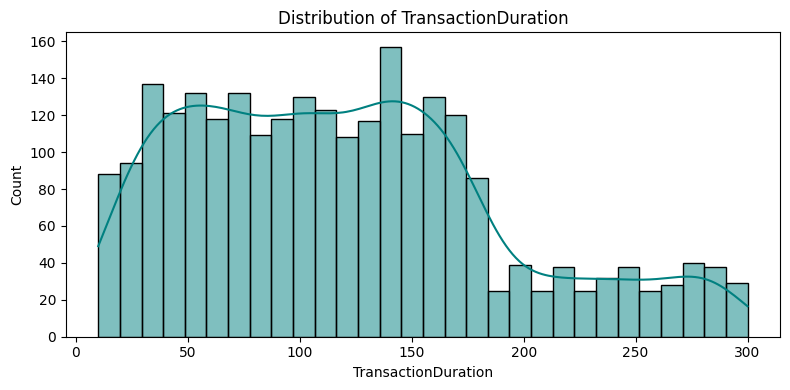

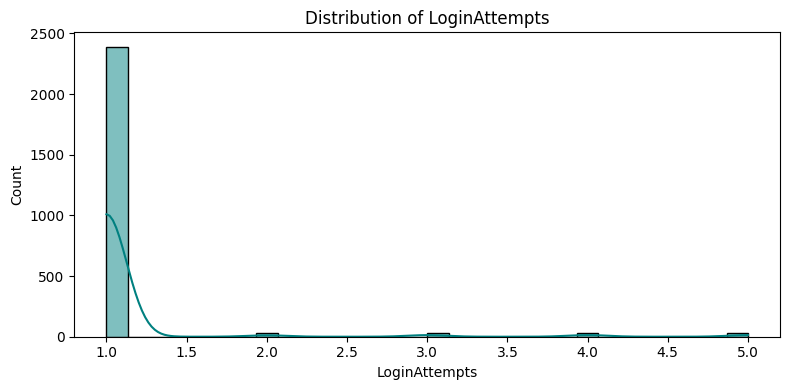

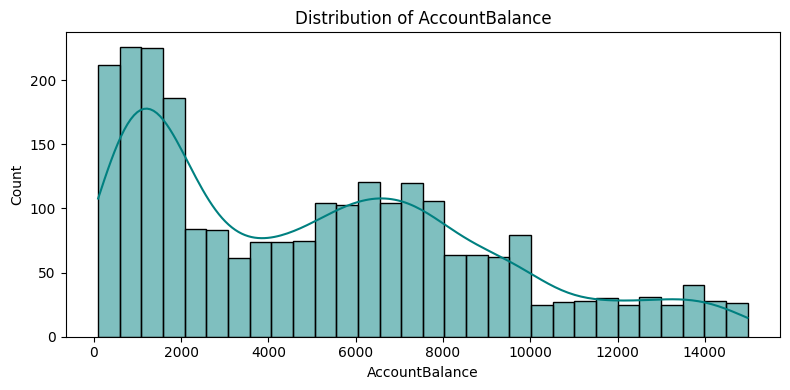

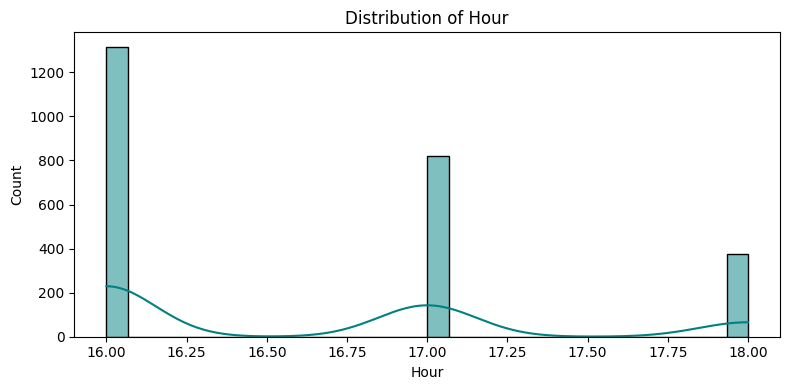

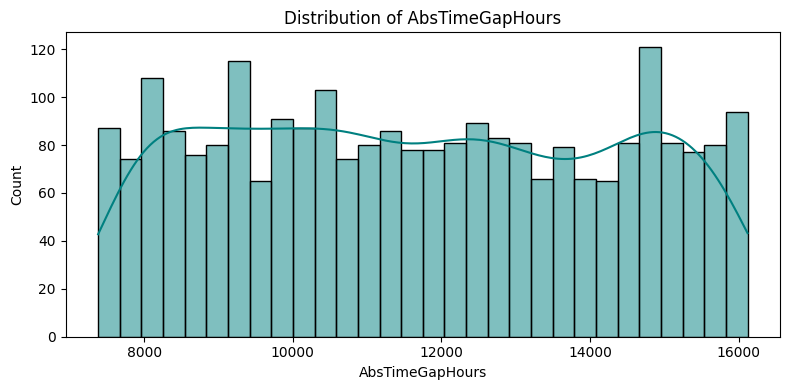

In [8]:
# Histograms
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30, color="teal")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

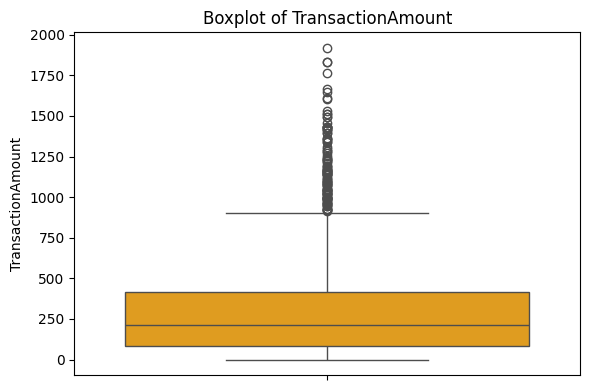

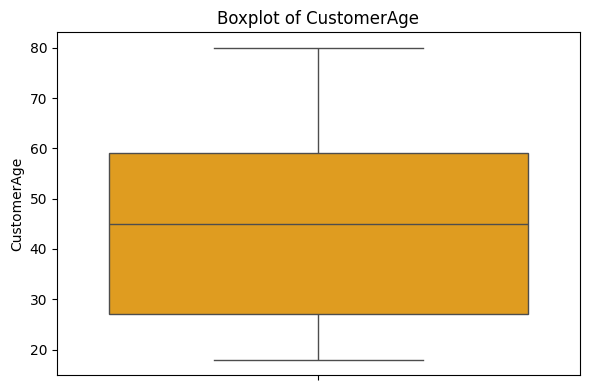

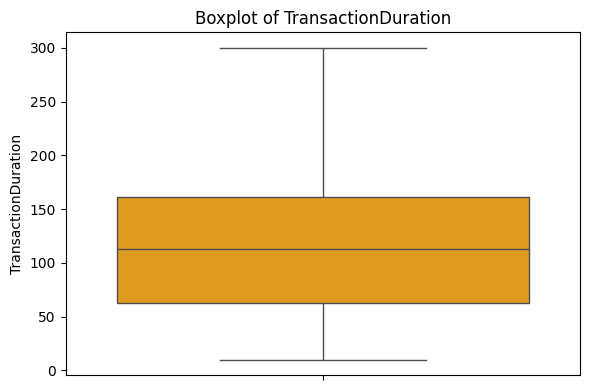

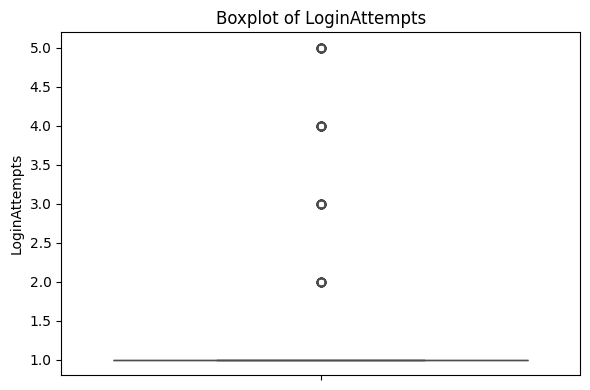

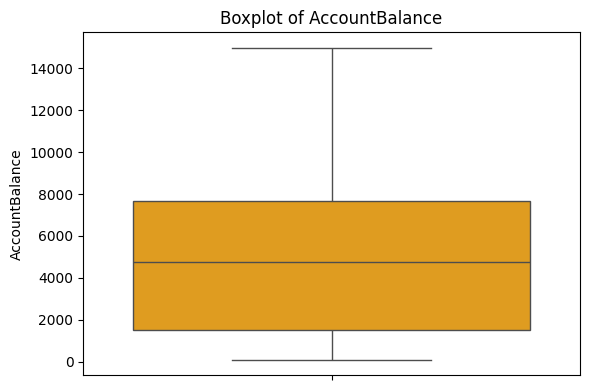

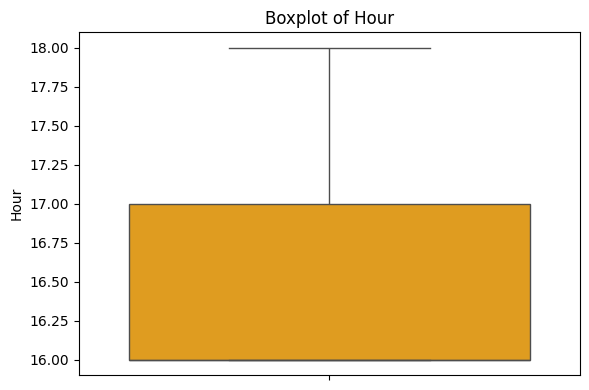

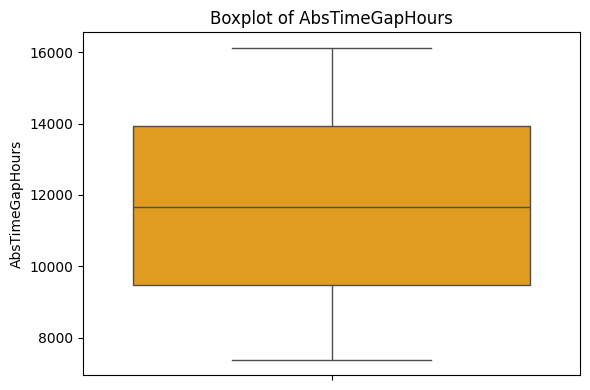

In [9]:
# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col], color="orange")
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


Top categories for TransactionType:
TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64


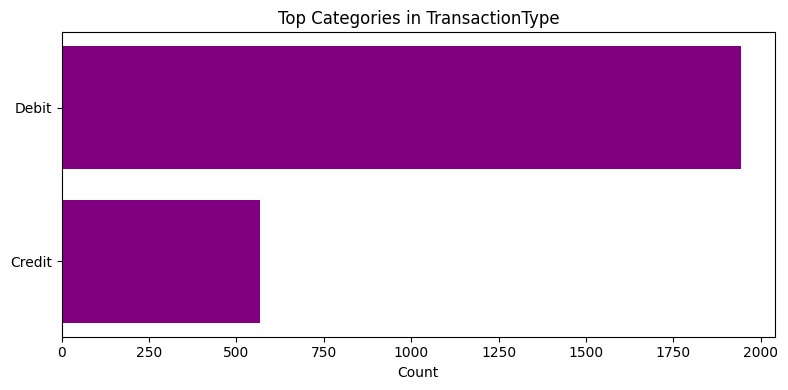


Top categories for Location:
Location
Fort Worth       70
Los Angeles      69
Oklahoma City    68
Charlotte        68
Philadelphia     67
Tucson           67
Omaha            65
Miami            64
Memphis          63
Detroit          63
Name: count, dtype: int64


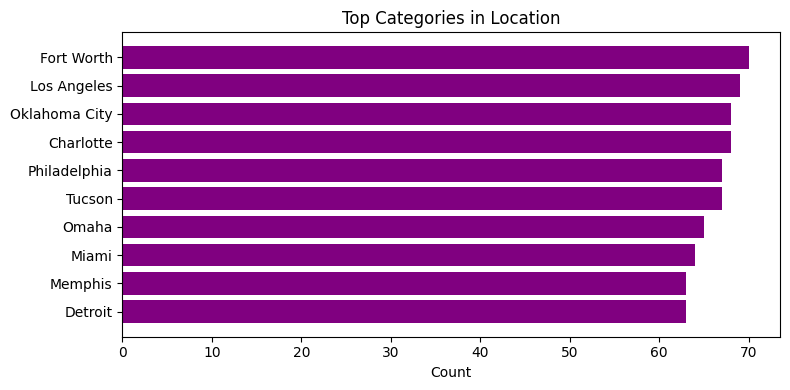


Top categories for Channel:
Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64


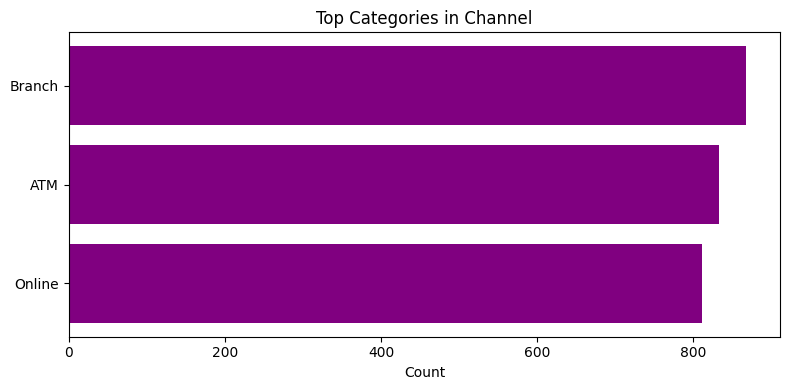


Top categories for CustomerOccupation:
CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64


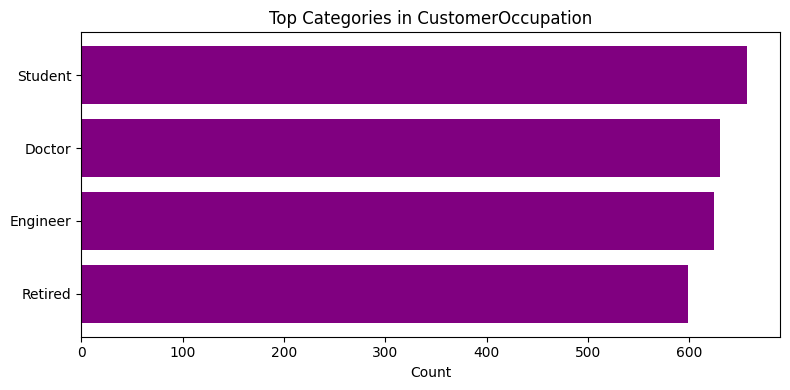


Top categories for DayOfWeek:
DayOfWeek
Monday       1070
Friday        373
Thursday      368
Tuesday       360
Wednesday     341
Name: count, dtype: int64


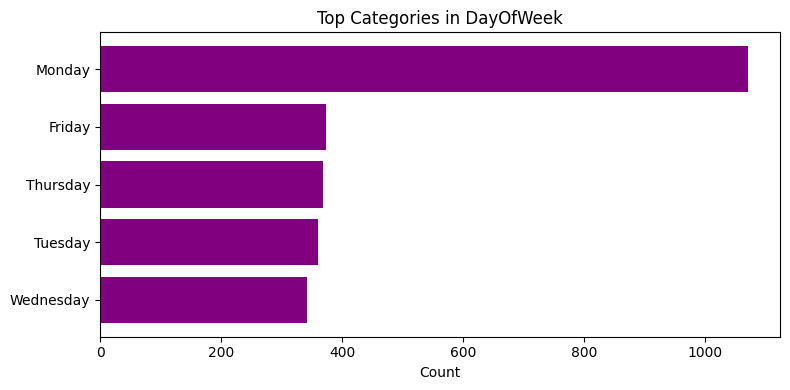

In [10]:
# Count plots
for col in categorical_cols:
    counts = df[col].value_counts().head(10)

    print(f"\nTop categories for {col}:")
    print(counts)

    plt.figure(figsize=(8, 4))
    plt.barh(counts.index.astype(str), counts.values, color="purple")
    plt.title(f"Top Categories in {col}")
    plt.xlabel("Count")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

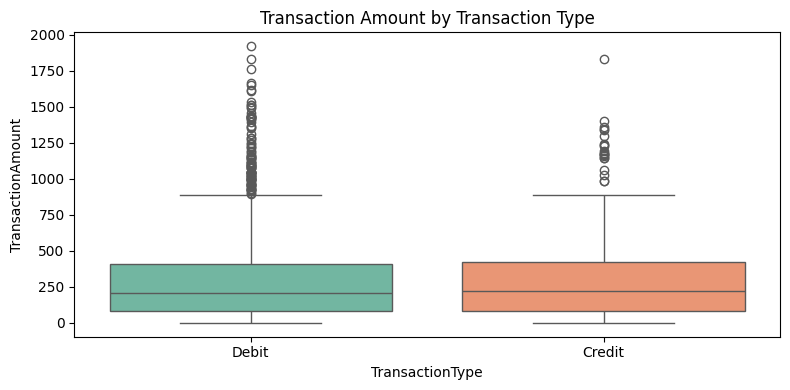

In [11]:
# 7. Bivariate Analysis

# Transaction amount by type
plt.figure(figsize=(8, 4))
sns.boxplot(x="TransactionType", y="TransactionAmount", data=df, palette="Set2")
plt.title("Transaction Amount by Transaction Type")
plt.tight_layout()
plt.show()

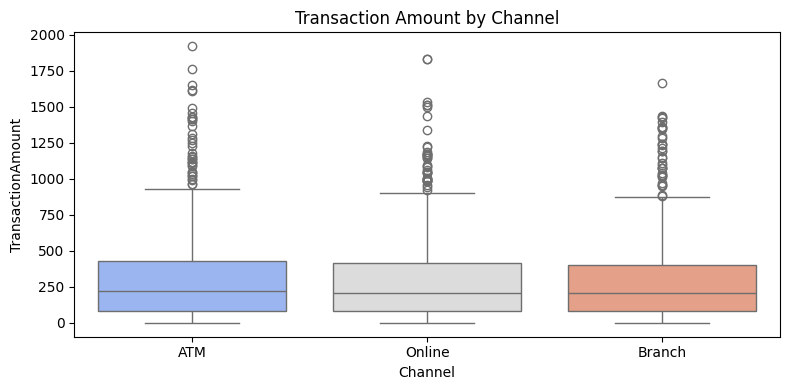

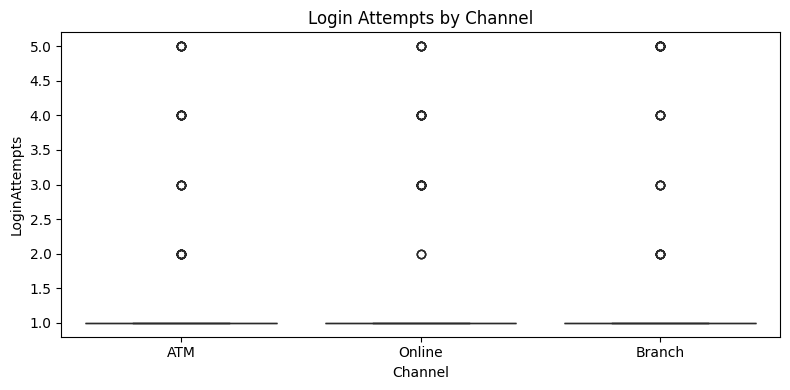

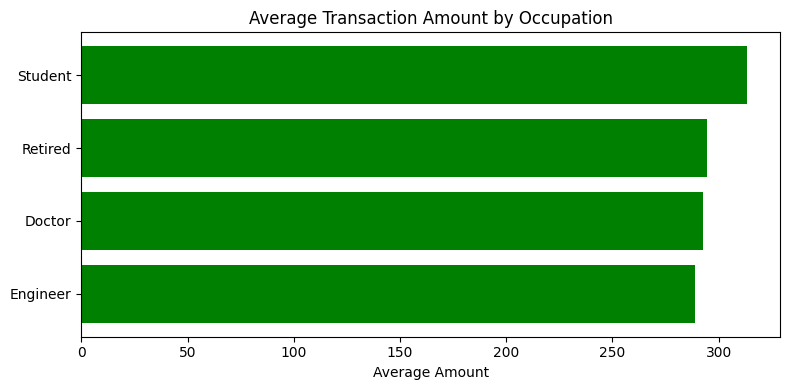

In [12]:
# Transaction amount by channel
plt.figure(figsize=(8, 4))
sns.boxplot(x="Channel", y="TransactionAmount", data=df, palette="coolwarm")
plt.title("Transaction Amount by Channel")
plt.tight_layout()
plt.show()

# Login attempts by channel
plt.figure(figsize=(8, 4))
sns.boxplot(x="Channel", y="LoginAttempts", data=df, palette="magma")
plt.title("Login Attempts by Channel")
plt.tight_layout()
plt.show()

# Average amount by occupation
avg_amount_occ = df.groupby("CustomerOccupation")["TransactionAmount"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.barh(avg_amount_occ.index, avg_amount_occ.values, color="green")
plt.title("Average Transaction Amount by Occupation")
plt.xlabel("Average Amount")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

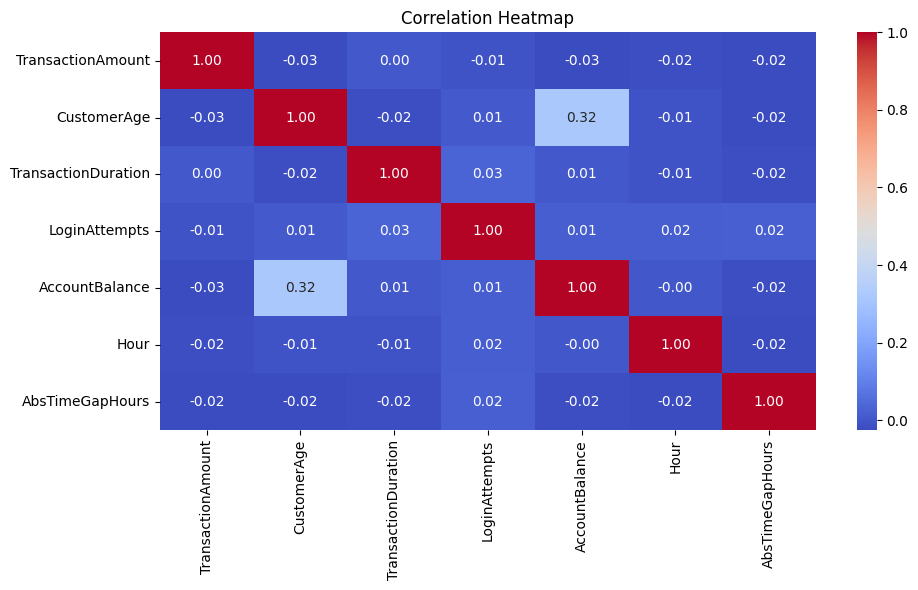

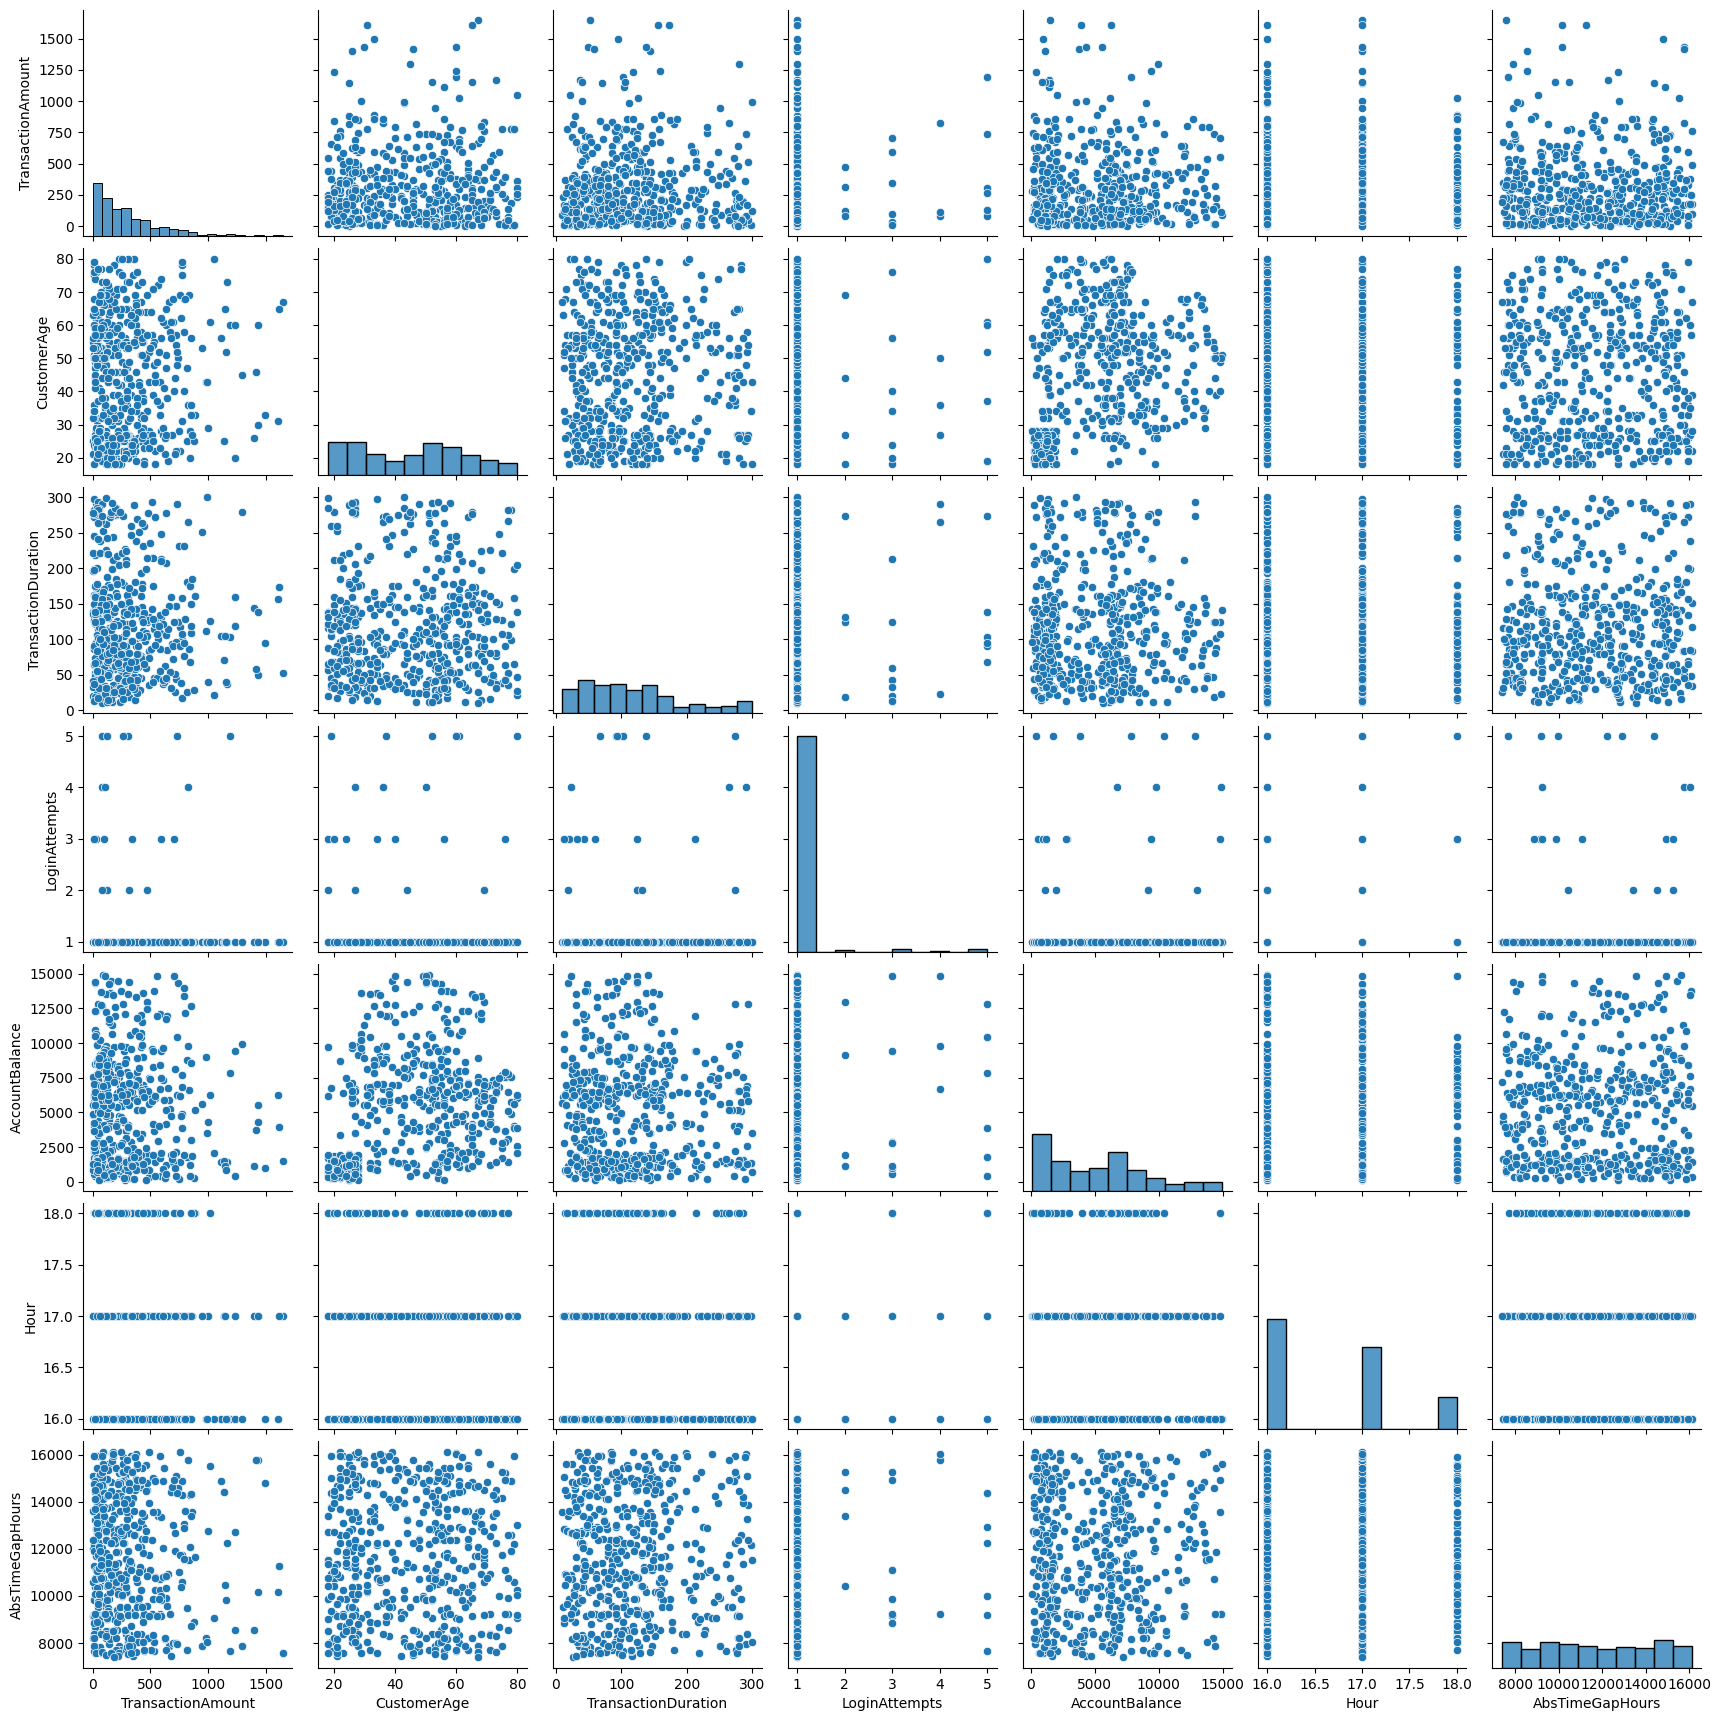

In [13]:
# 8. Multivariate Analysis

corr_cols = ["TransactionAmount", "CustomerAge", "TransactionDuration","LoginAttempts", "AccountBalance", "Hour", "AbsTimeGapHours"]

plt.figure(figsize=(10, 6))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

pairplot_sample = df[corr_cols].sample(min(500, len(df)), random_state=42)
sns.pairplot(pairplot_sample)
plt.show()

In [14]:
# 9. Feature Engineering

# account-level behavior metrics
acct_features = df.groupby("AccountID").agg(AccountTxnCount=("TransactionID", "count"),AvgTxnAmount=("TransactionAmount", "mean"),StdTxnAmount=("TransactionAmount", "std"),AvgLoginAttempts=("LoginAttempts", "mean")).reset_index()

df = df.merge(acct_features, on="AccountID", how="left")
df["StdTxnAmount"] = df["StdTxnAmount"].fillna(0)

df["AmountToBalanceRatio"] = df["TransactionAmount"] / df["AccountBalance"].replace(0, np.nan)
df["TxnAmountZByAccount"] = ((df["TransactionAmount"] - df["AvgTxnAmount"]) /df["StdTxnAmount"].replace(0, np.nan))
df["TxnAmountZByAccount"] = df["TxnAmountZByAccount"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["HighLoginFlag"] = (df["LoginAttempts"] >= df["LoginAttempts"].quantile(0.95)).astype(int)

print("\nEngineered Feature Sample:")
print(df[["TransactionAmount", "AccountBalance", "AmountToBalanceRatio","AccountTxnCount", "AvgTxnAmount", "TxnAmountZByAccount", "HighLoginFlag"]].head())


Engineered Feature Sample:
   TransactionAmount  AccountBalance  AmountToBalanceRatio  AccountTxnCount  \
0              14.09         5112.21              0.002756                7   
1             376.24        13758.91              0.027345                7   
2             126.29         1122.35              0.112523                4   
3             184.50         8569.06              0.021531                8   
4              13.45         7429.40              0.001810                6   

   AvgTxnAmount  TxnAmountZByAccount  HighLoginFlag  
0    460.698571            -0.915239              1  
1    304.622857             0.298035              1  
2    237.047500            -0.560249              1  
3    236.483750            -0.188923              1  
4    280.796667            -0.860385              1  


In [15]:
# 10. Prepare for anomaly detection

feature_cols_num = ["TransactionAmount", "CustomerAge", "TransactionDuration","LoginAttempts", "AccountBalance", "Hour", "IsWeekend","AbsTimeGapHours", "AccountTxnCount", "AvgTxnAmount","AmountToBalanceRatio", "TxnAmountZByAccount"]

feature_cols_cat = ["TransactionType", "Location", "Channel", "CustomerOccupation"]

X = df[feature_cols_num + feature_cols_cat].copy()

preprocessor = ColumnTransformer([("num", Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())]), feature_cols_num),("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))]), feature_cols_cat)])

X_prepared = preprocessor.fit_transform(X)

In [16]:
# 11. Anomaly Detection Model

iso_forest = IsolationForest(contamination=0.05,random_state=42,n_estimators=200)

df["AnomalyScore"] = -iso_forest.fit(X_prepared).score_samples(X_prepared)
df["AnomalyFlag"] = (iso_forest.predict(X_prepared) == -1).astype(int)

print("\nAnomaly count:", df["AnomalyFlag"].sum())
print("Anomaly percentage:", round(df["AnomalyFlag"].mean() * 100, 2), "%")


Anomaly count: 126
Anomaly percentage: 5.02 %


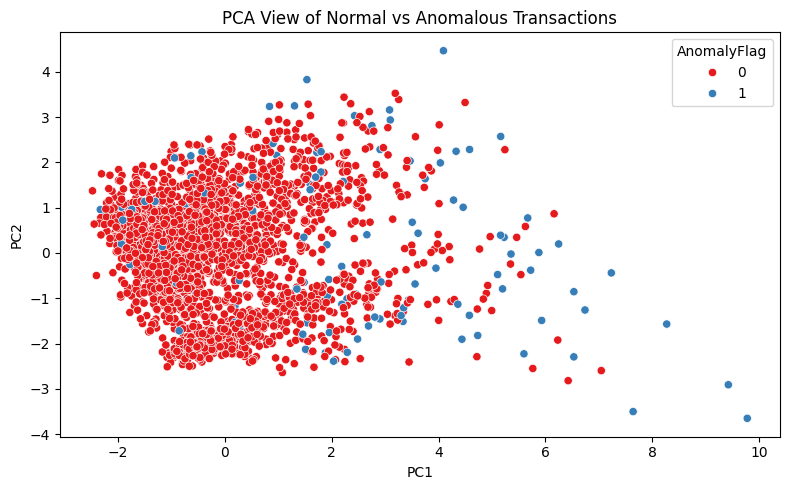

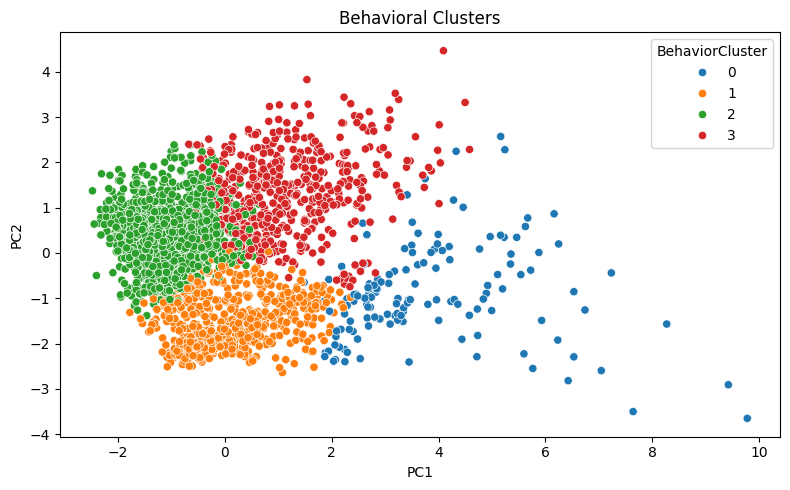

In [17]:
# 12. Cluster-based behavioral segmentation

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["BehaviorCluster"] = kmeans.fit_predict(X_prepared)

# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["AnomalyFlag"] = df["AnomalyFlag"]
pca_df["BehaviorCluster"] = df["BehaviorCluster"]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="AnomalyFlag", palette="Set1")
plt.title("PCA View of Normal vs Anomalous Transactions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="BehaviorCluster", palette="tab10")
plt.title("Behavioral Clusters")
plt.tight_layout()
plt.show()

In [18]:
# 13. Top anomalous transactions

top_anomalies = df.sort_values("AnomalyScore", ascending=False).head(20)
print("\nTop Anomalous Transactions:")
print(top_anomalies[["TransactionID", "AccountID", "TransactionAmount", "Channel","Location", "LoginAttempts", "AccountBalance","AmountToBalanceRatio", "TxnAmountZByAccount", "AnomalyScore"]])


Top Anomalous Transactions:
     TransactionID AccountID  TransactionAmount Channel          Location  \
274       TX000275   AC00454            1176.28     ATM       Kansas City   
898       TX000899   AC00083            1531.31  Online         San Diego   
934       TX000935   AC00456            1022.75  Branch          San Jose   
1213      TX001214   AC00170            1192.20  Branch      Jacksonville   
2124      TX002125   AC00039             737.46  Branch       Albuquerque   
147       TX000148   AC00161             514.95  Online          New York   
2191      TX002192   AC00131             879.25  Online           Memphis   
1557      TX001558   AC00245             262.43  Online         San Diego   
1273      TX001274   AC00431            1235.69  Branch          San Jose   
614       TX000615   AC00466            1342.25  Branch        Fort Worth   
1857      TX001858   AC00130             720.13     ATM             Omaha   
1575      TX001576   AC00379             732.53

In [19]:
# 14. Business interpretation

print("\nBusiness Insights:")
print("1. Large-value transactions relative to balance are more likely to appear unusual.")
print("2. High login attempts combined with unusual transaction context may indicate risk.")
print("3. Deviations from account-level normal transaction amount are useful anomaly signals.")
print("4. Transaction behavior differs across channels, occupations, and locations.")

print("\nRecommendations:")
print("1. Use anomaly scores to prioritize transactions for manual investigation.")
print("2. Add real fraud labels in future to move from anomaly detection to supervised fraud prediction.")
print("3. Trigger alerts when high login attempts and abnormal amount patterns occur together.")
print("4. Monitor account-level behavior drift over time for early fraud detection.")


Business Insights:
1. Large-value transactions relative to balance are more likely to appear unusual.
2. High login attempts combined with unusual transaction context may indicate risk.
3. Deviations from account-level normal transaction amount are useful anomaly signals.
4. Transaction behavior differs across channels, occupations, and locations.

Recommendations:
1. Use anomaly scores to prioritize transactions for manual investigation.
2. Add real fraud labels in future to move from anomaly detection to supervised fraud prediction.
3. Trigger alerts when high login attempts and abnormal amount patterns occur together.
4. Monitor account-level behavior drift over time for early fraud detection.
